## Clothing_Style_Recommended_System

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use("ggplot")

In [2]:
# Data Loading
df = pd.read_csv("Clothing_Retail_Dataset.csv")

In [3]:
df.head()

,Fashion_Era,Age,Gender,Height_cm,Weight_kg,Body_Type,Occasion,Season,Budget_INR,Preferred_Style,Favorite_Color,Fashion_Trend,Dress_Combination,Recommended_Top,Recommended_Bottom,Recommended_Footwear
0,1990,29,Female,156.0,67.0,Average,Office,Winter,7000,Grunge,Black,Timeless,Black + Grey + Black,Flannel Shirt,Ripped Jeans,Boots
1,1980,22,Male,172.0,75.0,Average,Office,Summer,1500,Power Dressing,Brown,Classic,Brown + Beige + Brown,Blazer,Formal Trousers,Formal Shoes
2,1970,29,Female,160.0,53.0,Athletic,Wedding,Winter,3000,Bohemian,Blue,Trending,Blue + Navy + Brown,Linen Shirt,Wide Leg Pants,Sandals
3,1950,25,Female,157.0,52.0,Athletic,Office,Monsoon,4000,Vintage,Blue,Sustainable,Blue + Grey + Black,Checked Shirt,Straight Jeans,Boots
4,1950,28,Male,172.0,73.0,Athletic,Office,Summer,5000,Classic,Grey,Timeless,Grey + Black + Brown,Oxford Shirt,Formal Trousers,Loafers


In [4]:
df.shape

(15001, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15001 entries, 0 to 15000
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fashion_Era           15001 non-null  int64  
 1   Age                   15001 non-null  int64  
 2   Gender                15001 non-null  str    
 3   Height_cm             14628 non-null  float64
 4   Weight_kg             14628 non-null  float64
 5   Body_Type             15001 non-null  str    
 6   Occasion              15001 non-null  str    
 7   Season                15001 non-null  str    
 8   Budget_INR            15001 non-null  int64  
 9   Preferred_Style       15001 non-null  str    
 10  Favorite_Color        14625 non-null  str    
 11  Fashion_Trend         14626 non-null  str    
 12  Dress_Combination     15001 non-null  str    
 13  Recommended_Top       15001 non-null  str    
 14  Recommended_Bottom    15001 non-null  str    
 15  Recommended_Footwear  15001 no

In [6]:
df.describe(include="object")

C:\Users\Hp\AppData\Local\Temp\ipykernel_18668\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Gender,Body_Type,Occasion,Season,Preferred_Style,Favorite_Color,Fashion_Trend,Dress_Combination,Recommended_Top,Recommended_Bottom,Recommended_Footwear
count,15001,15001,15001,15001,15001,14625,14626,15001,15001,15001,15001
unique,3,4,5,3,18,11,5,68,16,13,10
top,Male,Athletic,Casual,Summer,Minimalist,Black,Trending,Black + Blue + White,Oxford Shirt,Straight Jeans,Sneakers
freq,7673,6682,6725,5089,1319,2609,2958,921,1883,2312,3527


In [7]:
df.duplicated().sum()

np.int64(83)

In [8]:
df.drop_duplicates()

,Fashion_Era,Age,Gender,Height_cm,Weight_kg,Body_Type,Occasion,Season,Budget_INR,Preferred_Style,Favorite_Color,Fashion_Trend,Dress_Combination,Recommended_Top,Recommended_Bottom,Recommended_Footwear
0,1990,29,Female,156.0,67.0,Average,Office,Winter,7000,Grunge,Black,Timeless,Black + Grey + Black,Flannel Shirt,Ripped Jeans,Boots
1,1980,22,Male,172.0,75.0,Average,Office,Summer,1500,Power Dressing,Brown,Classic,Brown + Beige + Brown,Blazer,Formal Trousers,Formal Shoes
2,1970,29,Female,160.0,53.0,Athletic,Wedding,Winter,3000,Bohemian,Blue,Trending,Blue + Navy + Brown,Linen Shirt,Wide Leg Pants,Sandals
3,1950,25,Female,157.0,52.0,Athletic,Office,Monsoon,4000,Vintage,Blue,Sustainable,Blue + Grey + Black,Checked Shirt,Straight Jeans,Boots
4,1950,28,Male,172.0,73.0,Athletic,Office,Summer,5000,Classic,Grey,Timeless,Grey + Black + Brown,Oxford Shirt,Formal Trousers,Loafers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14993,1980,18,Male,180.0,80.0,Athletic,Office,Winter,4000,Power Dressing,NaN,Classic,Black + Grey + Black,Blazer,Formal Trousers,Formal Shoes
14994,1950,31,Male,172.0,62.0,Athletic,Party,Summer,1500,Classic,Brown,Trending,Brown + Navy + Brown,Oxford Shirt,Formal Trousers,Loafers
14995,2000,28,Male,174.0,84.0,Average,Casual,Summer,3000,Casual,Beige,Trending,Beige + Olive + White,Polo Shirt,Chinos,Sneakers
14996,1980,23,Female,156.0,32.0,Slim,Casual,Winter,25000,Power Dressing,White,Classic,White + Blue + White,Blazer,Formal Trousers,Formal Shoes


In [9]:
# Data Cleaning

df["Height_cm"] = df["Height_cm"].fillna(df["Height_cm"].median())

In [10]:
df["Weight_kg"] = df["Weight_kg"].fillna(df["Weight_kg"].median())

In [11]:
df["Favorite_Color"] = df["Favorite_Color"].fillna(df["Favorite_Color"].mode()[0])

In [12]:
df["Fashion_Trend"] = df["Fashion_Trend"].fillna(df["Fashion_Trend"].mode()[0])

In [13]:
df.isnull().sum()

Fashion_Era             0
Age                     0
Gender                  0
Height_cm               0
Weight_kg               0
Body_Type               0
Occasion                0
Season                  0
Budget_INR              0
Preferred_Style         0
Favorite_Color          0
Fashion_Trend           0
Dress_Combination       0
Recommended_Top         0
Recommended_Bottom      0
Recommended_Footwear    0
dtype: int64

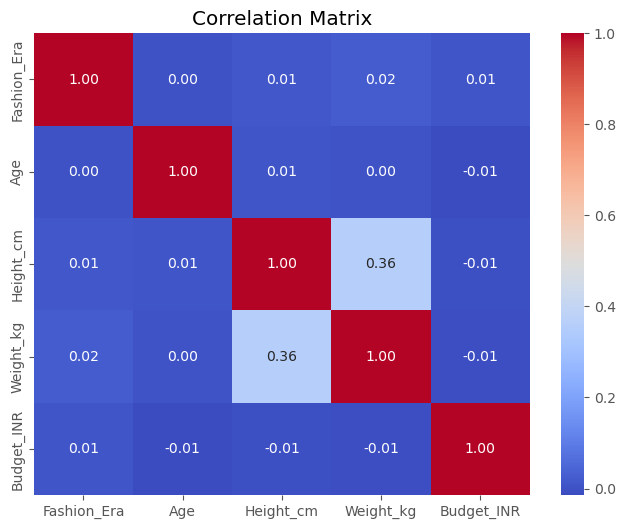

In [14]:
# EDA

num_cols = ['Fashion_Era', 'Age', 'Height_cm', 'Weight_kg', 'Budget_INR']

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()



<Axes: xlabel='Age', ylabel='Count'>

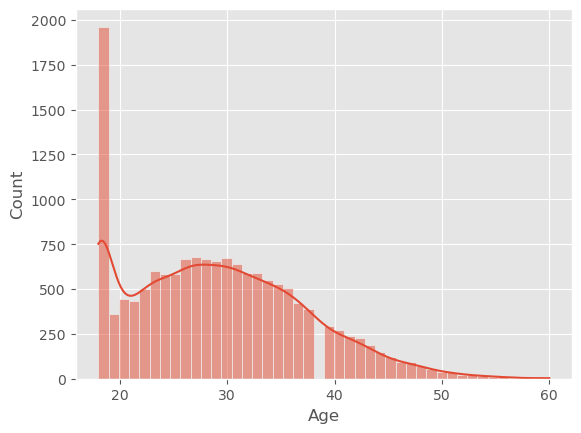

In [15]:
sns.histplot(df["Age"], kde=True)

INSIGHT : Customer Between 20-35yr, and we have the young customer segment

<Axes: xlabel='Budget_INR'>

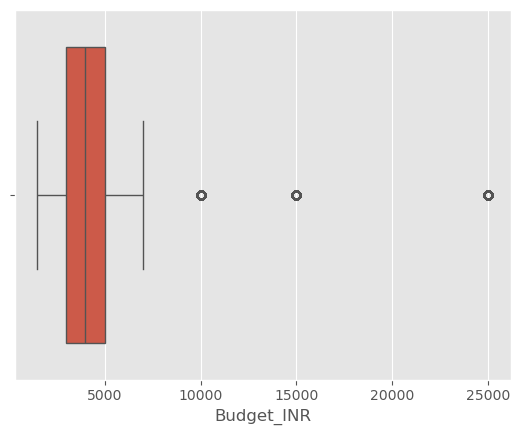

In [16]:
sns.boxplot(x=df["Budget_INR"])

INSIGHT : Customer Budget Between 2k to 7k with some premium shoppers.

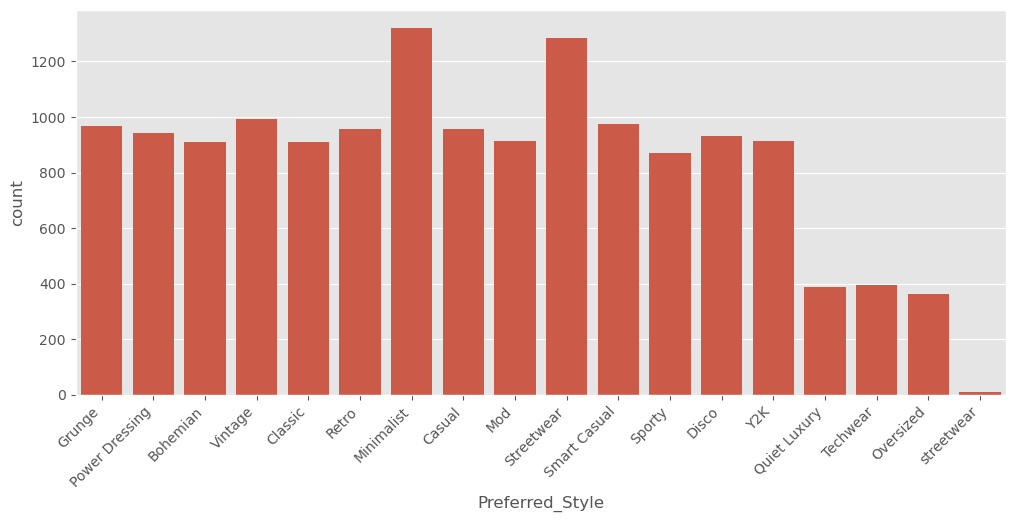

In [17]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="Preferred_Style")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.show()

INSIGHT : Streetwear and Minimalist are the most popular style

In [18]:
df["BMI"] = df["Weight_kg"]/((df["Height_cm"]/100)** 2)

df["BMI"] = df["BMI"].round(2)

In [19]:
df.head()

,Fashion_Era,Age,Gender,Height_cm,Weight_kg,Body_Type,Occasion,Season,Budget_INR,Preferred_Style,Favorite_Color,Fashion_Trend,Dress_Combination,Recommended_Top,Recommended_Bottom,Recommended_Footwear,BMI
0,1990,29,Female,156.0,67.0,Average,Office,Winter,7000,Grunge,Black,Timeless,Black + Grey + Black,Flannel Shirt,Ripped Jeans,Boots,27.53
1,1980,22,Male,172.0,75.0,Average,Office,Summer,1500,Power Dressing,Brown,Classic,Brown + Beige + Brown,Blazer,Formal Trousers,Formal Shoes,25.35
2,1970,29,Female,160.0,53.0,Athletic,Wedding,Winter,3000,Bohemian,Blue,Trending,Blue + Navy + Brown,Linen Shirt,Wide Leg Pants,Sandals,20.70
3,1950,25,Female,157.0,52.0,Athletic,Office,Monsoon,4000,Vintage,Blue,Sustainable,Blue + Grey + Black,Checked Shirt,Straight Jeans,Boots,21.10
4,1950,28,Male,172.0,73.0,Athletic,Office,Summer,5000,Classic,Grey,Timeless,Grey + Black + Brown,Oxford Shirt,Formal Trousers,Loafers,24.68


In [20]:
df["Gender"] = df["Gender"].replace("male","Male")

In [21]:
df["Gender"].value_counts()

Gender
Male      7748
Female    7253
Name: count, dtype: int64

In [22]:
columns = ["Gender"]

mapping = {
    "Female": 0,
    "Male": 1
}

for col in columns:
    df[col] = df[col].map(mapping)

In [23]:
df.head()

,Fashion_Era,Age,Gender,Height_cm,Weight_kg,Body_Type,Occasion,Season,Budget_INR,Preferred_Style,Favorite_Color,Fashion_Trend,Dress_Combination,Recommended_Top,Recommended_Bottom,Recommended_Footwear,BMI
0,1990,29,0,156.0,67.0,Average,Office,Winter,7000,Grunge,Black,Timeless,Black + Grey + Black,Flannel Shirt,Ripped Jeans,Boots,27.53
1,1980,22,1,172.0,75.0,Average,Office,Summer,1500,Power Dressing,Brown,Classic,Brown + Beige + Brown,Blazer,Formal Trousers,Formal Shoes,25.35
2,1970,29,0,160.0,53.0,Athletic,Wedding,Winter,3000,Bohemian,Blue,Trending,Blue + Navy + Brown,Linen Shirt,Wide Leg Pants,Sandals,20.70
3,1950,25,0,157.0,52.0,Athletic,Office,Monsoon,4000,Vintage,Blue,Sustainable,Blue + Grey + Black,Checked Shirt,Straight Jeans,Boots,21.10
4,1950,28,1,172.0,73.0,Athletic,Office,Summer,5000,Classic,Grey,Timeless,Grey + Black + Brown,Oxford Shirt,Formal Trousers,Loafers,24.68


In [24]:
from sklearn.preprocessing import LabelEncoder
import joblib

Enco = df.select_dtypes(include="object").columns

encoders = {}

for col in Enco:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "encoders.pkl")

C:\Users\Hp\AppData\Local\Temp\ipykernel_18668\2730504194.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Enco = df.select_dtypes(include="object").columns


['encoders.pkl']

In [25]:
df.head()

,Fashion_Era,Age,Gender,Height_cm,Weight_kg,Body_Type,Occasion,Season,Budget_INR,Preferred_Style,Favorite_Color,Fashion_Trend,Dress_Combination,Recommended_Top,Recommended_Bottom,Recommended_Footwear,BMI
0,1990,29,0,156.0,67.0,1,2,2,7000,4,1,3,13,2,6,0,27.53
1,1980,22,1,172.0,75.0,1,2,1,1500,8,3,0,23,0,4,3,25.35
2,1970,29,0,160.0,53.0,0,4,2,3000,0,2,4,22,4,12,7,20.70
3,1950,25,0,157.0,52.0,0,2,0,4000,15,2,2,19,1,8,0,21.10
4,1950,28,1,172.0,73.0,0,2,1,5000,2,5,3,36,8,4,5,24.68


In [26]:
# Training Data
X = df[
    [
        "Fashion_Era",
        "Age",
        "Gender",
        "Height_cm",
        "Weight_kg",
        "BMI",
        "Body_Type",
        "Occasion",
        "Season",
        "Budget_INR",
        "Preferred_Style",
        "Favorite_Color",
        "Fashion_Trend"
    ]
]

In [27]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [28]:
y = df[
    [
        "Recommended_Top",
        "Recommended_Bottom",
        "Recommended_Footwear",
        "Dress_Combination"
    ]
]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state= 42
)



In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 13)
(3001, 13)
(12000, 4)
(3001, 4)


In [31]:
# First Model:

from sklearn.multioutput import ClassifierChain
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model = ClassifierChain(
    rf,
    order = [0,1,2,3]
)
model.fit(X_train,y_train)

,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,RandomForestC...ndom_state=42)
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.","[0, 1, ...]"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.",None
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
,"base_estimator base_estimator: estimator, default=""deprecated""Use `estimator` instead... deprecated:: 1.7 `base_estimator` is deprecated and will be removed in 1.9. Use `estimator` instead.",'deprecated'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

accuracy = []

for i, col in enumerate(y.columns):
    acc = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
    accuracy.append(acc)

print("Accuracy : ", np.mean(accuracy))

Accuracy :  0.904865044985005


In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score


In [40]:
rf_precision = []

for i in range(y_test.shape[1]):
    precision = precision_score(
        y_test.iloc[:, i],
        y_pred[:, i],
        average="weighted",
        zero_division=0
    )
    rf_precision.append(precision)

print("Random Forest Precision:", np.mean(rf_precision))


Random Forest Precision: 0.8960616880064414


In [41]:
rf_recall = []

for i in range(y_test.shape[1]):
    recall = recall_score(
        y_test.iloc[:, i],
        y_pred[:, i],
        average="weighted",
        zero_division=0
    )
    rf_recall.append(recall)

print("Random Forest Recall:", np.mean(rf_recall))

Random Forest Recall: 0.904865044985005


In [42]:
rf_f1 = []

for i in range(y_test.shape[1]):
    f1 = f1_score(
        y_test.iloc[:, i],
        y_pred[:, i],
        average="weighted",
        zero_division=0
    )
    rf_f1.append(f1)

print("Random Forest F1 Score:", np.mean(rf_f1))

Random Forest F1 Score: 0.8969402152896374


In [46]:
# Random Forest Training Prediction

rf_train_pred = model.predict(X_train)

train_accuracy = []

for i in range(y_train.shape[1]):
    accuracy = accuracy_score(
        y_train.iloc[:, i],
        rf_train_pred[:, i]
    )
    train_accuracy.append(accuracy)

print("Random Forest Train Accuracy:", np.mean(train_accuracy))
print("Random Forest Test Accuracy:", np.mean(accuracy))

Random Forest Train Accuracy: 0.9992083333333334
Random Forest Test Accuracy: 0.9968333333333333


In [34]:
# Second Model:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

xgb_model = MultiOutputClassifier(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric="mlogloss"
    )
)

xgb_model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,"XGBClassifier...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [35]:
y_pred_xgb = xgb_model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

accuracy = []

for i, col in enumerate(y.columns):
    acc = accuracy_score(y_test.iloc[:, i], y_pred_xgb[:, i])
    accuracy.append(acc)

print("Accuracy : ", np.mean(accuracy))

Accuracy :  0.9111962679106964


In [54]:
y_pred_xgb = xgb_model.predict(X_test)

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [53]:
# Precision
xgb_precision = []

for i in range(y_test.shape[1]):
    precision = precision_score(
        y_test.iloc[:, i],
        y_pred_xgb[:, i],
        average="weighted",
        zero_division=0
    )
    xgb_precision.append(precision)

print("XGBoost Precision:", np.mean(xgb_precision))

XGBoost Precision: 0.9034262310341399


In [52]:
# Recall
xgb_recall = []

for i in range(y_test.shape[1]):
    recall = recall_score(
        y_test.iloc[:, i],
        y_pred_xgb[:, i],
        average="weighted",
        zero_division=0
    )
    xgb_recall.append(recall)

print("XGBoost Recall:", np.mean(xgb_recall))

XGBoost Recall: 0.9111962679106964


In [51]:
# F1 Score
xgb_f1 = []

for i in range(y_test.shape[1]):
    f1 = f1_score(
        y_test.iloc[:, i],
        y_pred_xgb[:, i],
        average="weighted",
        zero_division=0
    )
    xgb_f1.append(f1)

print("XGBoost F1 Score:", np.mean(xgb_f1))

XGBoost F1 Score: 0.9041837762005844


In [50]:
# XGBoost Training Prediction

xgb_train_pred = xgb_model.predict(X_train)

train_accuracy = []

for i in range(y_train.shape[1]):
    accuracy = accuracy_score(
        y_train.iloc[:, i],
        xgb_train_pred[:, i]
    )
    train_accuracy.append(accuracy)

print("XGBoost Train Accuracy:", np.mean(train_accuracy))
print("XGBoost Test Accuracy:", np.mean(accuracy))

XGBoost Train Accuracy: 0.9991666666666666
XGBoost Test Accuracy: 0.9966666666666667


### Random Forest Model Accuracy has 90.4% Where xgboost Model Has 91.1%

In [37]:
import joblib

joblib.dump(xgb_model, "clothing_recommendation_system.pkl")


['clothing_recommendation_system.pkl']